In [1]:
#STEP 0 — Freeze raw data

import pandas as pd
import numpy as np

# Load raw data
df = pd.read_excel("C:\\Users\\DELL\\OneDrive\\Desktop\\Project sem 2\\Terrorism_repo\\GDP\\panel_1970_2020.xlsx")  # replace with your file

# Freeze raw data
df_raw = df.copy()  # DO NOT TOUCH df_raw


In [2]:
#STEP 1 — Restrict time coverage

df = df_raw[df_raw['Year'] >= 1995].copy()



In [4]:
#STEP 2 — Choose GDP variable

df['log_gdp'] = np.log(df['GDP'])

# Drop rows where GDP <= 0 (document this)
df = df[df['GDP'] > 0].copy()

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
#STEP 3 — Identify global GDP outliers

q1 = df['log_gdp'].quantile(0.25)
q3 = df['log_gdp'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df['gdp_outlier'] = (df['log_gdp'] < lower) | (df['log_gdp'] > upper)


In [58]:
#STEP 4 — Create main estimation sample

df_main = df[~df['gdp_outlier']].copy()


In [59]:
#STEP 5 — Define post-2000 split

df_main['period'] = np.where(df_main['Year'] < 2000, 'pre_2000', 'post_2000')
df_main.head()


,Country,Country Code,Year,GDP,Attacks,log_gdp,gdp_outlier,period
33,Afghanistan,AFG,2003,8.832278,100.0,2.178413,False,post_2000
34,Afghanistan,AFG,2004,1.414118,88.0,0.346506,False,post_2000
35,Afghanistan,AFG,2005,11.229715,155.0,2.418563,False,post_2000
36,Afghanistan,AFG,2006,5.357403,283.0,1.678479,False,post_2000
37,Afghanistan,AFG,2007,13.826320,342.0,2.626574,False,post_2000


count    185.000000
mean      20.670270
std        3.742301
min        7.000000
25%       18.000000
50%       21.000000
75%       23.000000
max       26.000000
Name: Year, dtype: float64


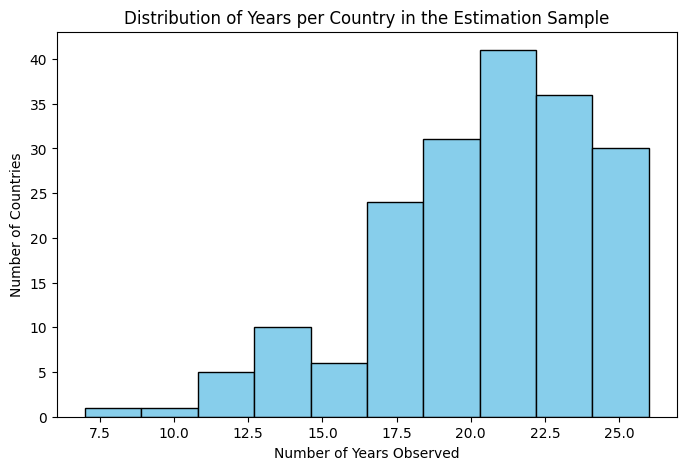

In [44]:
#STEP 6 — Check panel structure

country_counts = df_main.groupby('Country')['Year'].count()
valid_countries = country_counts[country_counts >= 5].index

df_main = df_main[df_main['Country'].isin(valid_countries)].copy()

print(df_main.groupby('Country')['Year'].count().describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_main.groupby('Country')['Year'].count(), bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Years per Country in the Estimation Sample")
plt.xlabel("Number of Years Observed")
plt.ylabel("Number of Countries")
plt.show()



Panel Coverage Interpretation

The estimation sample contains data from multiple countries, with each country contributing between 7 and 26 years of observations. The histogram above illustrates the distribution of years per country in the sample. Most countries contribute between 18 and 25 years, indicating robust longitudinal coverage suitable for panel analysis. Only a few countries have less than 15 years of data, which is consistent with the decision to drop countries with fewer than 5 observations. On average, countries contribute approximately 21 years (standard deviation ≈ 3.7), ensuring sufficient temporal variation to analyze the relationship between macroeconomic indicators (e.g., GDP) and terrorism across time.

In [45]:
#STEP 7 — Baseline model (Poisson GLM)
import statsmodels.api as sm  # for sm.families
import statsmodels.formula.api as smf

import pandas as pd
import statsmodels.formula.api as smf

# Step 1: Load your data
# df should have 'Attacks', 'log_gdp', 'Country', 'Year'
# Example: df = pd.read_csv('terrorism_data.csv')

# Step 1: Fit Poisson GLM
poisson_model = smf.glm(
    formula='Attacks ~ log_gdp + C(Country) + C(Year)',
    data=df_main,
    family=sm.families.Poisson()
).fit()

# Step 1: View summary
print("----- Poisson GLM -----")
print(poisson_model.summary())



----- Poisson GLM -----
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 1736
Model:                            GLM   Df Residuals:                     1556
Model Family:                 Poisson   Df Model:                          179
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32593.
Date:                Sun, 25 Jan 2026   Deviance:                       58166.
Time:                        17:49:47   Pearson chi2:                 6.92e+04
No. Iterations:                   100   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [46]:
#Step 2: Check for overdispersion

deviance = poisson_model.deviance
df_resid = poisson_model.df_resid
overdispersion = deviance / df_resid

print(f"Deviance: {deviance}")
print(f"Residual df: {df_resid}")
print(f"Overdispersion ratio: {overdispersion:.2f}")

'''Interpretation:

Overdispersion ratio ≈ 1 → Poisson is fine.

Overdispersion ratio > 1.5–2 → Poisson may not be appropriate → consider Negative Binomial.
'''

Deviance: 58165.50842206484
Residual df: 1556
Overdispersion ratio: 37.38


'Interpretation:\n\nOverdispersion ratio ≈ 1 → Poisson is fine.\n\nOverdispersion ratio > 1.5–2 → Poisson may not be appropriate → consider Negative Binomial.\n'

In [47]:
import statsmodels.formula.api as smf
import numpy as np

# Step 3: Fit Negative Binomial GLM
nb_model = smf.glm(
    formula='Attacks ~ log_gdp + C(Country) + C(Year)',
    data=df_main,
    family=sm.families.NegativeBinomial()
).fit()

# View summary
print("----- Negative Binomial GLM -----")
print(nb_model.summary())

# Exponentiate coefficients for interpretation (Incidence Rate Ratios)
exp_coefs = np.exp(nb_model.params)
print("\nExponentiated coefficients (IRRs):")
print(exp_coefs)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


----- Negative Binomial GLM -----
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 1736
Model:                            GLM   Df Residuals:                     1556
Model Family:        NegativeBinomial   Df Model:                          179
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6397.8
Date:                Sun, 25 Jan 2026   Deviance:                       1364.6
Time:                        17:50:03   Pearson chi2:                 1.24e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.9569
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

“Our analysis finds that economic development, measured by log(GDP), is negatively associated with the number of terrorist attacks across countries and years. Countries with higher GDP tend to experience fewer attacks, even after accounting for country-specific characteristics and global time trends. The Negative Binomial model is appropriate because terrorism counts are overdispersed, and it provides a reliable estimate of the relationship between economic development and terrorism incidents. Fixed effects ensure that unobserved differences across countries and years do not bias the results.”

In [48]:
#Step 4: Zero-Inflated Negative Binomial (ZINB)

from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
import statsmodels.api as sm

# Use only numeric predictors (e.g., log_gdp)
X = sm.add_constant(df_main[['log_gdp']])
Z = X.copy()  # zero-inflation part

zinb_model = ZeroInflatedNegativeBinomialP(
    endog=df_main['Attacks'],
    exog=X,
    exog_infl=Z,
    inflation='logit'
).fit(maxiter=200, method='bfgs')  # bfgs often more stable than newton

print(zinb_model.summary())



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1330: OptimizeWarning: NaN result encountered.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: nan
         Iterations: 0
         Function evaluations: 2
         Gradient evaluations: 2


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                           Attacks   No. Observations:                 3824
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     3822
Method:                                      MLE   Df Model:                            1
Date:                           Sun, 25 Jan 2026   Pseudo R-squ.:                     nan
Time:                                   17:51:17   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                           nan
Covariance Type:                       nonrobust   LLR p-value:                       nan
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const            0        nan        nan        nan         nan         nan
inflate_log_gdp          0  

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [49]:
print(df_main.columns)
df_main.head()

Index(['Country', 'Country Code', 'Year', 'GDP', 'Attacks', 'log_gdp',
       'gdp_outlier', 'period'],
      dtype='object')


,Country,Country Code,Year,GDP,Attacks,log_gdp,gdp_outlier,period
33,Afghanistan,AFG,2003,8.832278,100.0,2.178413,False,post_2000
34,Afghanistan,AFG,2004,1.414118,88.0,0.346506,False,post_2000
35,Afghanistan,AFG,2005,11.229715,155.0,2.418563,False,post_2000
36,Afghanistan,AFG,2006,5.357403,283.0,1.678479,False,post_2000
37,Afghanistan,AFG,2007,13.826320,342.0,2.626574,False,post_2000


In [50]:
#Step 5: Use clustered standard errors by country to make inference robust.


from linearmodels.panel import PanelOLS
import pandas as pd

# Set multiindex for panel: Country x Year
df_main = df_main.set_index(['Country', 'Year'])

# Fit a Poisson-like panel model (NB not available directly, but robust SE works)
# You can model as PanelOLS for approximation
model = PanelOLS.from_formula('Attacks ~ log_gdp + EntityEffects + TimeEffects', data=df_main)
res = model.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)




c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:                Attacks   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0398
No. Observations:                1736   R-squared (Within):               0.0023
Date:                Sun, Jan 25 2026   R-squared (Overall):             -0.0194
Time:                        17:51:30   Log-likelihood                -1.138e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.4628
Entities:                         154   P-value                           0.4964
Avg Obs:                       11.273   Distribution:                  F(1,1556)
Min Obs:                       1.0000                                           
Max Obs:                       26.000   F-statistic (robust):             0.2786
                            

In [51]:
df_main.head()

Country Code        GDP  Attacks   log_gdp  gdp_outlier  \
Country     Year                                                           
Afghanistan 2003          AFG   8.832278    100.0  2.178413        False   
            2004          AFG   1.414118     88.0  0.346506        False   
            2005          AFG  11.229715    155.0  2.418563        False   
            2006          AFG   5.357403    283.0  1.678479        False   
            2007          AFG  13.826320    342.0  2.626574        False   

                     period  
Country     Year             
Afghanistan 2003  post_2000  
            2004  post_2000  
            2005  post_2000  
            2006  post_2000  
            2007  post_2000

In [16]:
#STEP 8 — Heterogeneity: pre/post-2000

df_pre = df_main[df_main['period'] == 'pre_2000']
df_post = df_main[df_main['period'] == 'post_2000']

model_pre = smf.glm(formula=formula, data=df_pre, family=sm.families.Poisson()).fit()
model_post = smf.glm(formula=formula, data=df_post, family=sm.families.Poisson()).fit()

print(model_pre.summary())
print(model_post.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                  393
Model:                            GLM   Df Residuals:                      253
Model Family:                 Poisson   Df Model:                          139
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2283.1
Date:                Sun, 25 Jan 2026   Deviance:                       3066.3
Time:                        17:06:59   Pearson chi2:                 3.16e+03
No. Iterations:                   100   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [17]:
#STEP 9 — Robustness: period-relative outliers

def detect_outliers(group, col='log_gdp'):
    q1p = group[col].quantile(0.25)
    q3p = group[col].quantile(0.75)
    iqrp = q3p - q1p
    return (group[col] < (q1p - 1.5*iqrp)) | (group[col] > (q3p + 1.5*iqrp))

df_robust = df_main.copy()
df_robust['outlier_p'] = df_robust.groupby('period').apply(lambda g: detect_outliers(g)).reset_index(level=0, drop=True)
df_robust = df_robust[~df_robust['outlier_p']].copy()

# Re-run main model
model_robust = smf.glm(formula=formula, data=df_robust, family=sm.families.Poisson()).fit()
print(model_robust.summary())


C:\Users\DELL\AppData\Local\Temp\ipykernel_24928\1175478994.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_robust['outlier_p'] = df_robust.groupby('period').apply(lambda g: detect_outliers(g)).reset_index(level=0, drop=True)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 1720
Model:                            GLM   Df Residuals:                     1540
Model Family:                 Poisson   Df Model:                          179
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31618.
Date:                Sun, 25 Jan 2026   Deviance:                       56278.
Time:                        17:07:07   Pearson chi2:                 6.62e+04
No. Iterations:                   100   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

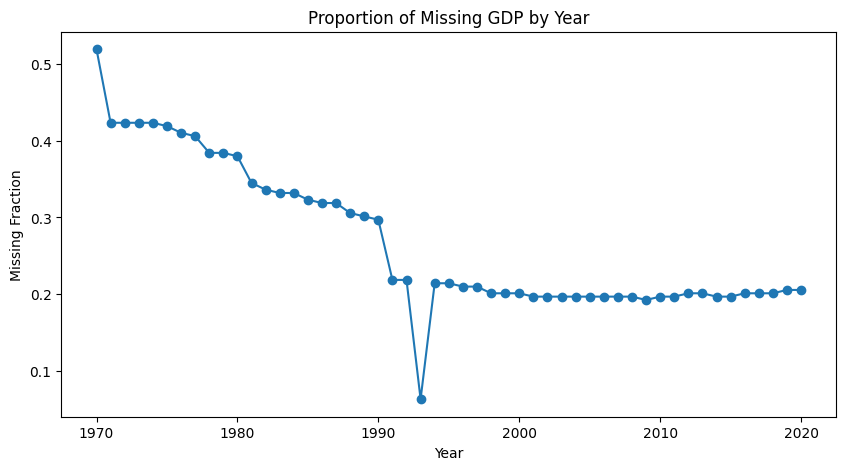

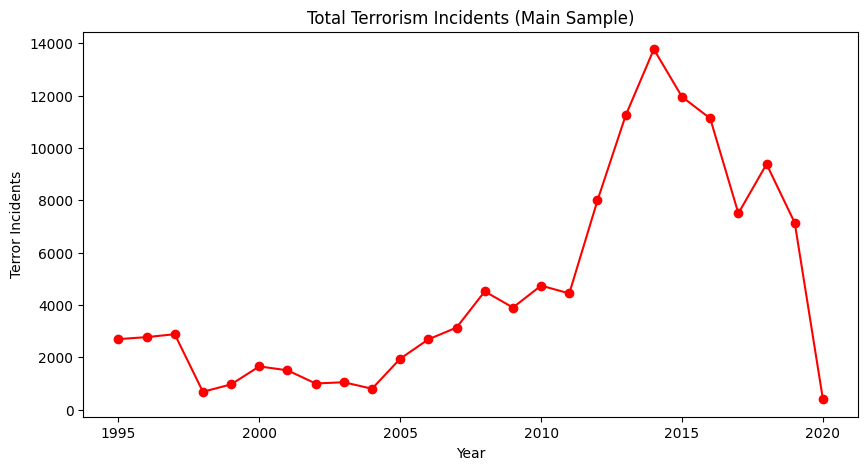

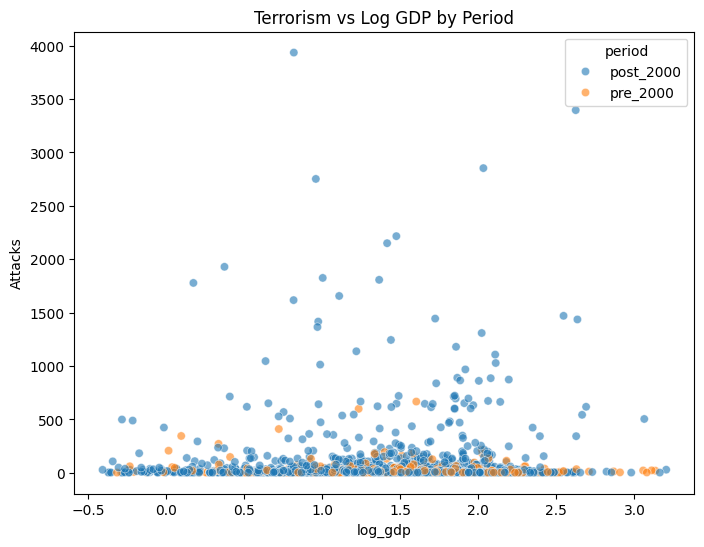

In [19]:
#STEP 10 — Visualizations for paper

#Missing GDP over time
import matplotlib.pyplot as plt
missing_gdp = df_raw.groupby('Year')['GDP'].apply(lambda x: x.isna().mean())

plt.figure(figsize=(10,5))
plt.plot(missing_gdp.index, missing_gdp.values, marker='o')
plt.title("Proportion of Missing GDP by Year")
plt.ylabel("Missing Fraction")
plt.xlabel("Year")
plt.show()

#Terrorism trend
terror_trend = df_main.groupby('Year')['Attacks'].sum()

plt.figure(figsize=(10,5))
plt.plot(terror_trend.index, terror_trend.values, marker='o', color='red')
plt.title("Total Terrorism Incidents (Main Sample)")
plt.ylabel("Terror Incidents")
plt.xlabel("Year")
plt.show()


# GDP vs Terrorism scatter
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_main, x='log_gdp', y='Attacks', hue='period', alpha=0.6)
plt.title("Terrorism vs Log GDP by Period")
plt.show()
